# Data Information
- This notebook trains a logistic regression model which contains movie reviews with a positive or negative label

### Install sklearn: python library for machine learning

In [2]:
pip install scikit-learn

### Install datasets: access IMDB dataset

In [3]:
pip install datasets

In [4]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")["train"]
print(imdb_dataset[-1])

{'text': 'The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.', 'label': 1}


### Look at IMDB reviews in DataFrame

In [5]:
import pandas as pd
df = pd.DataFrame(imdb_dataset)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

Number of rows: 25000
Number of columns: 2


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


### Convert training data into format scikit-learn expects
- Input vectors (documents) and a list of associated output labels

In [6]:
train_data = []
train_data_labels = []
for item in imdb_dataset:
    train_data.append(item["text"])
    train_data_labels.append(item["label"])

print(train_data[5])
print(train_data_labels[5])

I would put this at the top of my list of films in the category of unwatchable trash! There are films that are bad, but the worst kind are the ones that are unwatchable but you are suppose to like them because they are supposed to be good for you! The sex sequences, so shocking in its day, couldn't even arouse a rabbit. The so called controversial politics is strictly high school sophomore amateur night Marxism. The film is self-consciously arty in the worst sense of the term. The photography is in a harsh grainy black and white. Some scenes are out of focus or taken from the wrong angle. Even the sound is bad! And some people call this art?<br /><br />
0


This is a film review and its label. We can clearly see that this is a negative film review. We see this with key phrases such as "unwatchable trash", "Even the sound is bad!" and a sarcastic remark at the end, "And some people call this art?"

The label for this review is 0. We can assume: 1 = positive review | 0 = negative review

### Import CountVectorizer
- Use the CountVectorizer class to extract the words in each review as the features the algorithm will learn from.
- Each document is represented as a 500 dimension vector of word counts. Only the 500 most frequent words are used in this version.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer="word", max_features=500, lowercase=True)
features = vectorizer.fit_transform(train_data).toarray()

Check we have a 2-D array where each row is one of 25,000 instances. Each column is one of 200 words. Print out words that will be used classification

In [8]:
print(features.shape)
print(vectorizer.get_feature_names_out())

(25000, 500)
['10' 'able' 'about' 'absolutely' 'act' 'acting' 'action' 'actor' 'actors'
 'actress' 'actually' 'after' 'again' 'against' 'all' 'almost' 'along'
 'already' 'also' 'although' 'always' 'am' 'amazing' 'american' 'an' 'and'
 'another' 'any' 'anyone' 'anything' 'are' 'around' 'art' 'as' 'at'
 'audience' 'away' 'awful' 'back' 'bad' 'based' 'be' 'beautiful' 'because'
 'become' 'becomes' 'been' 'before' 'beginning' 'behind' 'being' 'believe'
 'best' 'better' 'between' 'big' 'bit' 'black' 'book' 'boring' 'both'
 'boy' 'br' 'budget' 'but' 'by' 'called' 'came' 'camera' 'can' 'car'
 'care' 'case' 'cast' 'certainly' 'character' 'characters' 'child'
 'children' 'cinema' 'classic' 'close' 'come' 'comedy' 'comes'
 'completely' 'could' 'couldn' 'couple' 'course' 'dark' 'day' 'days'
 'dead' 'death' 'definitely' 'despite' 'dialogue' 'did' 'didn' 'different'
 'direction' 'director' 'do' 'does' 'doesn' 'doing' 'don' 'done' 'down'
 'drama' 'during' 'dvd' 'each' 'early' 'effects' 'either' 'else

Split the data into a training and validation (dev) set. We'll use the validation set to test our model. 90% data for training | 10% data for testing

## Make Predictions: Logistic Regression

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x_train, x_val, y_train, y_val = train_test_split(features, train_data_labels, train_size=0.9, random_state=123)

model = LogisticRegression()
model = model.fit(X=x_train, y=y_train)

y_pred = model.predict(X=x_val)

# Test accuracy of model
print(f"Accuracy of Model: {accuracy_score(y_val, y_pred)*100}%")

Accuracy of Model: 82.6%


C:\Users\humay\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Confusion Matrix

[[1062  197]
 [ 238 1003]]


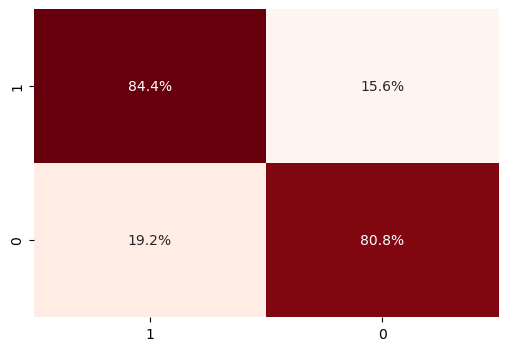

In [10]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = [1, 0]

cm = confusion_matrix(y_val, y_pred, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Positive: Just over 84% of positive reviews were correctly predicted as positive = 1062
- False Positive: Almost 16% of positive review were incorrectly predicted as negative = 197
- True Negative: Almost 81% of negative reviews were correctly predicted as negative = 1003
- False Negative: Just over 19% of negative review were incorrectly predicted as positive = 238

## Attempt to Increase Accuracy: Logistic Regression

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer with similar parameters
vectorizer_new = TfidfVectorizer(analyzer="word", max_features=5000, lowercase=True)

# Fit and transform the training data
features_new = vectorizer_new.fit_transform(train_data).toarray()

x_train_new, x_val_new, y_train_new, y_val_new = train_test_split(features_new, train_data_labels,
                                                                  train_size=0.9, random_state=123)

model_new = LogisticRegression()
model_new = model_new.fit(X=x_train_new, y=y_train_new)

y_pred_new = model_new.predict(X=x_val_new)

# Compare accuracy of new model
print(f"Accuracy of Old Model: {accuracy_score(y_val, y_pred)*100}%")
print(f"Accuracy of New Model: {accuracy_score(y_val_new, y_pred_new)*100}%")

Accuracy of Old Model: 82.6%
Accuracy of New Model: 87.52%
